In [1]:
import pickle
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
import torch
from neuralhydrology.evaluation import metrics, eval_wrapper, comp_plots
from neuralhydrology.nh_run import start_run, eval_run

In [8]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'
exp_name ='EXP03'
default_order = ['SW_train','noSW_train','SW_test','noSW_test']
seqlen_options = [10,30,60,90,270]

### Evaluate run on test set
Change the `run_dir` argument by grabbing from:
1. above training output log
2. below list of runs

In [3]:
all_runs = os.listdir(all_runs_dir)
exp_runs = [run for run in all_runs if exp_name in run]
exp_runs.sort()
exp_runs

['EXP03_seqlen_no_sw_10_10basins_2608_144004',
 'EXP03_seqlen_no_sw_270_10basins_2608_145500',
 'EXP03_seqlen_no_sw_30_10basins_2608_144239',
 'EXP03_seqlen_no_sw_60_10basins_2608_144553',
 'EXP03_seqlen_no_sw_90_10basins_2608_144942',
 'EXP03_seqlen_wi_sw_10_10basins_2608_141137',
 'EXP03_seqlen_wi_sw_270_10basins_2608_142822',
 'EXP03_seqlen_wi_sw_30_10basins_2608_141444',
 'EXP03_seqlen_wi_sw_60_10basins_2608_141815',
 'EXP03_seqlen_wi_sw_90_10basins_2608_142239']

In [4]:
seq10_metrics = eval_wrapper.quick_eval(fp_no_sw='EXP03_seqlen_no_sw_10_10basins_2608_144004',
    fp_wi_sw='EXP03_seqlen_wi_sw_10_10basins_2608_141137',
    run_dir = all_runs_dir)
seq30_metrics = eval_wrapper.quick_eval(fp_no_sw='EXP03_seqlen_no_sw_30_10basins_2608_144239',
    fp_wi_sw='EXP03_seqlen_wi_sw_30_10basins_2608_141444',
    run_dir = all_runs_dir)
seq60_metrics = eval_wrapper.quick_eval(fp_no_sw='EXP03_seqlen_no_sw_60_10basins_2608_144553',
    fp_wi_sw='EXP03_seqlen_wi_sw_60_10basins_2608_141815',
    run_dir = all_runs_dir)
seq90_metrics = eval_wrapper.quick_eval(fp_no_sw='EXP03_seqlen_no_sw_90_10basins_2608_144942',
    fp_wi_sw='EXP03_seqlen_wi_sw_90_10basins_2608_142239',
    run_dir = all_runs_dir)
seq270_metrics = eval_wrapper.quick_eval(fp_no_sw='EXP03_seqlen_no_sw_270_10basins_2608_145500',
    fp_wi_sw='EXP03_seqlen_wi_sw_270_10basins_2608_142822',
    run_dir = all_runs_dir)

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP03_seqlen_wi_sw_10_10basins_2608_141137
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP03_seqlen_wi_sw_10_10basins_2608_141137
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP03_seqlen_no_sw_10_10basins_2608_144004
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP03_seqlen_no_sw_10_10basins_2608_144004
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
Loaded model results
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP03_se

In [10]:
tuple1 = ('swtrain1','notrain1','swtest1','notest1')
tuple2 = ('swtrain2','notrain2','swtest1','notest2')

5

In [13]:
zipped_metrics = list(zip(seq10_metrics,seq30_metrics,seq60_metrics,seq90_metrics,seq270_metrics))

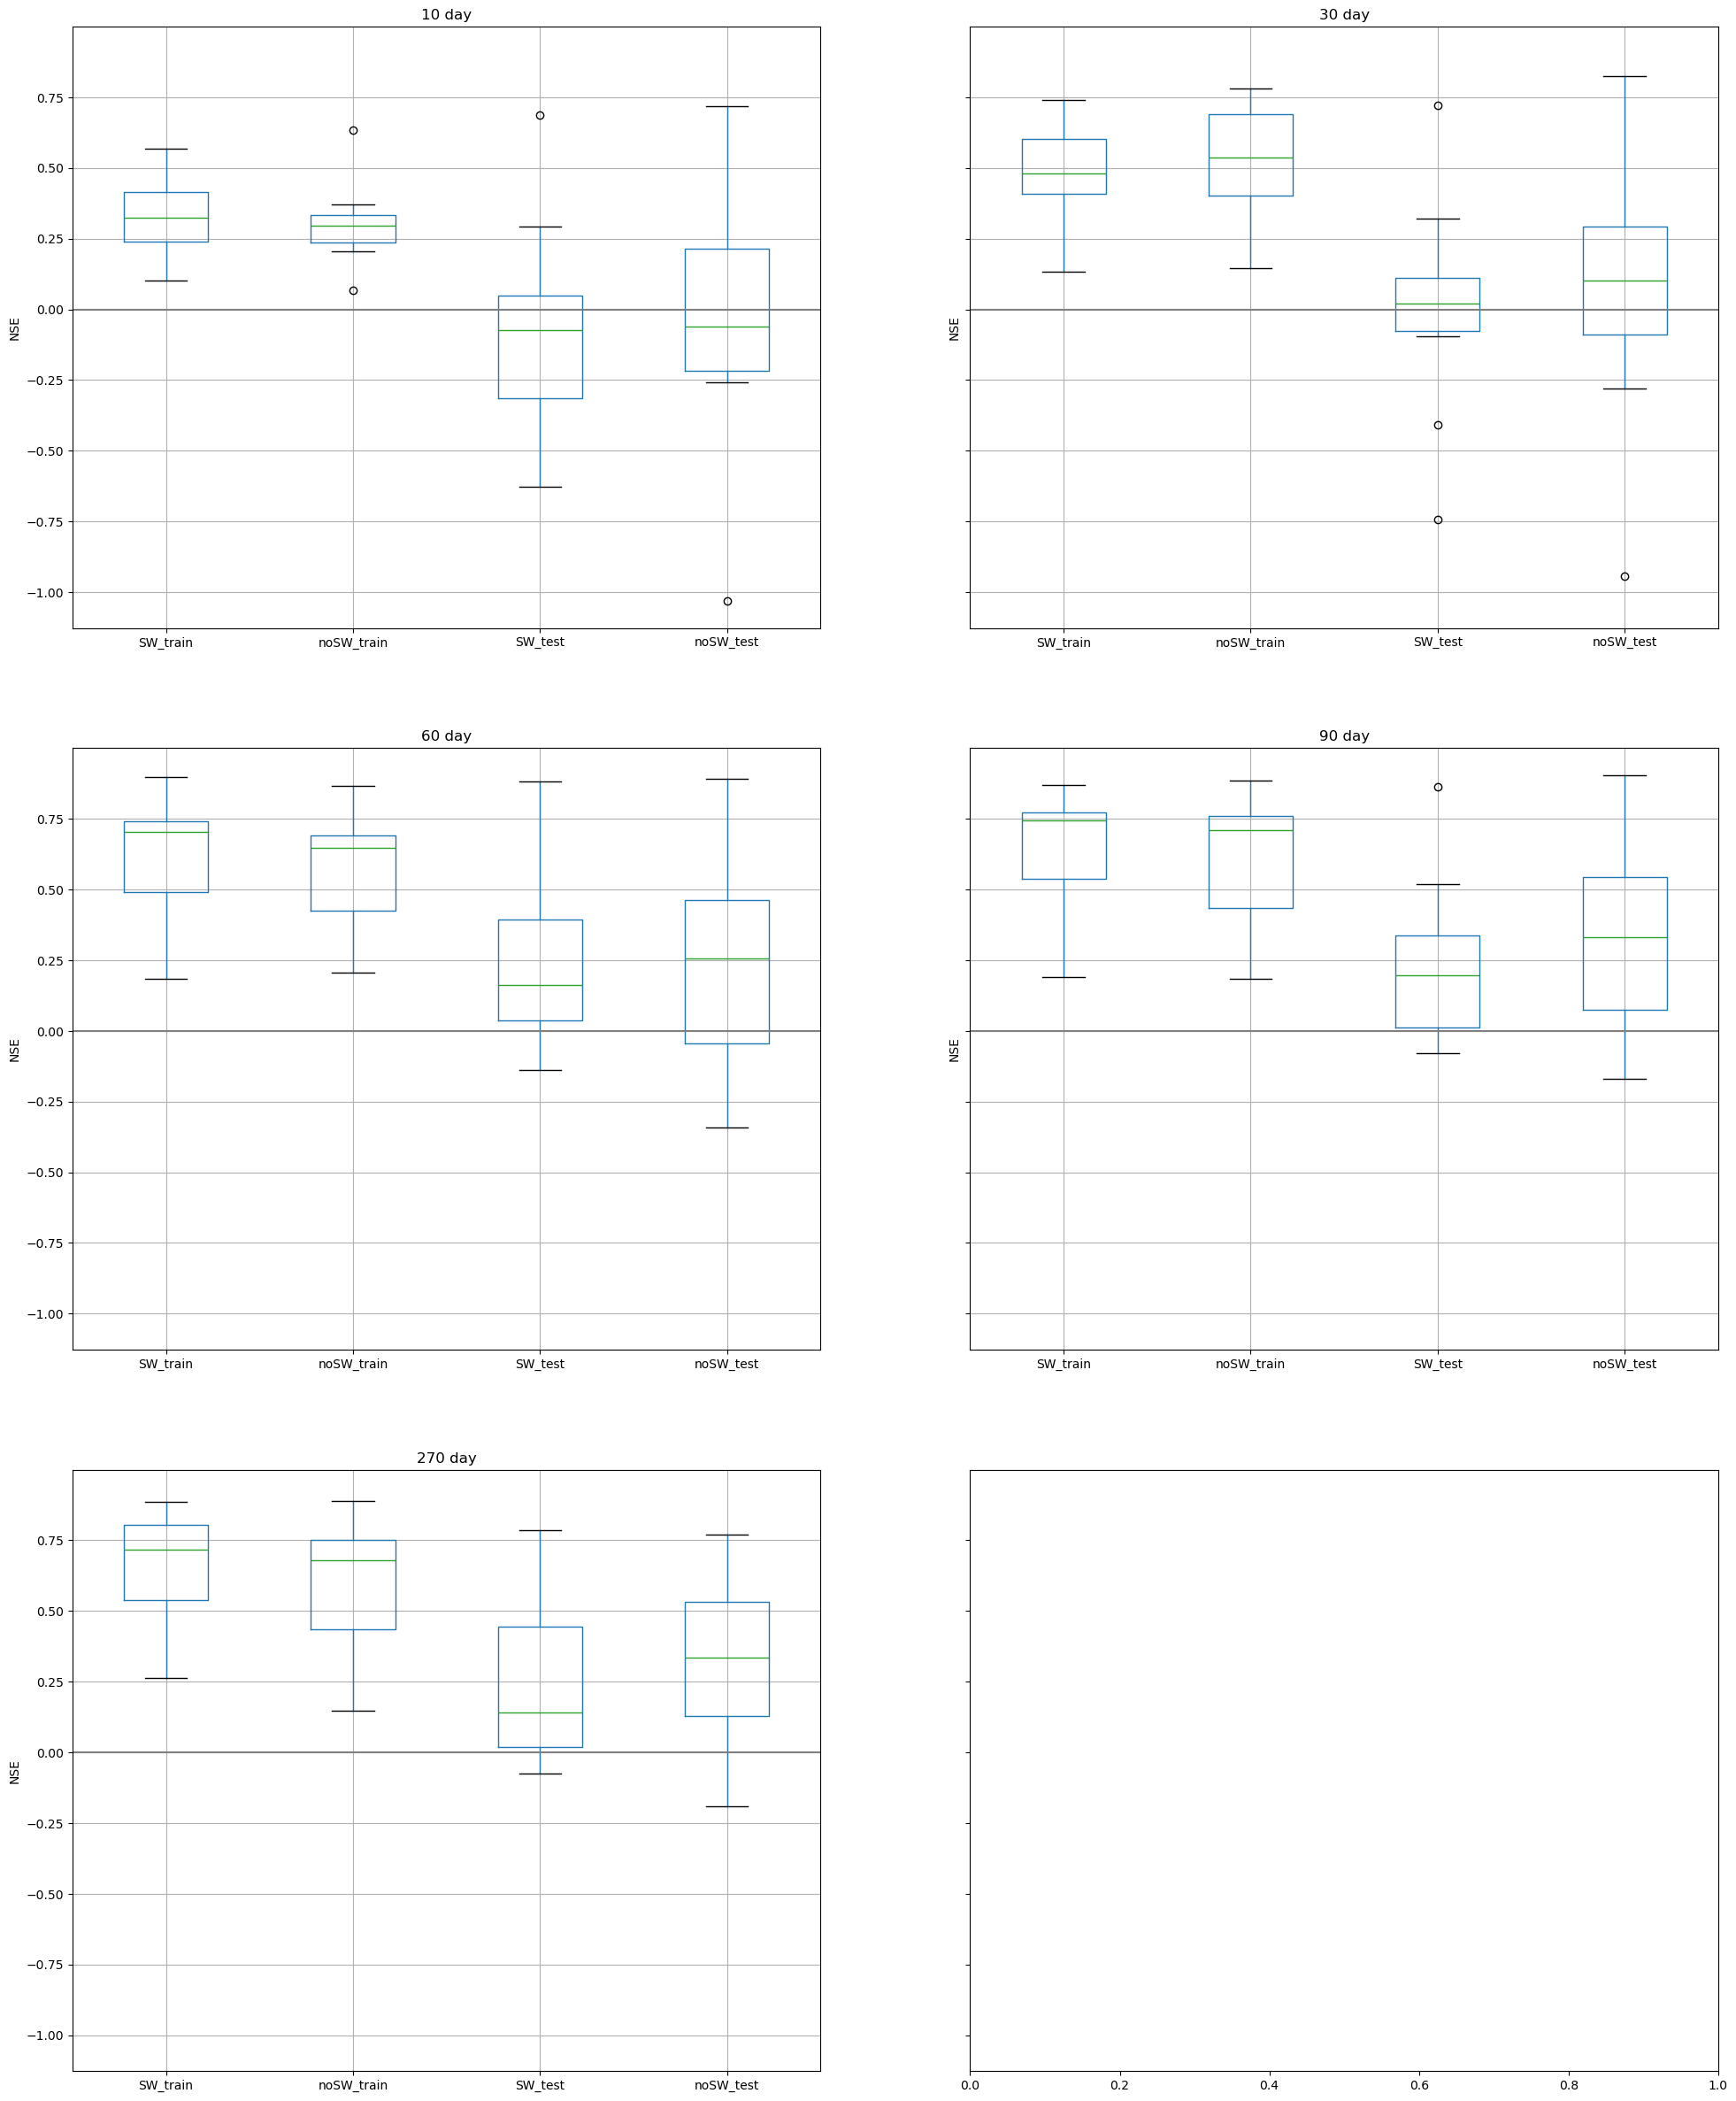

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(24, 30),sharey=True)
seq10_nse_df = comp_plots.boxplot_from_tuple(seq10_metrics,ax=axs[0,0],tuple_names=default_order,exp_name = '10 day')
seq30_nse_df = comp_plots.boxplot_from_tuple(seq30_metrics,ax=axs[0,1],tuple_names=default_order,exp_name = '30 day')
seq60_nse_df = comp_plots.boxplot_from_tuple(seq60_metrics,ax=axs[1,0],tuple_names=default_order,exp_name = '60 day')
seq90_nse_df = comp_plots.boxplot_from_tuple(seq90_metrics,ax=axs[1,1],tuple_names=default_order,exp_name = '90 day')
seq270_nse_df = comp_plots.boxplot_from_tuple(seq270_metrics,ax=axs[2,0],tuple_names=default_order,exp_name = '270 day')

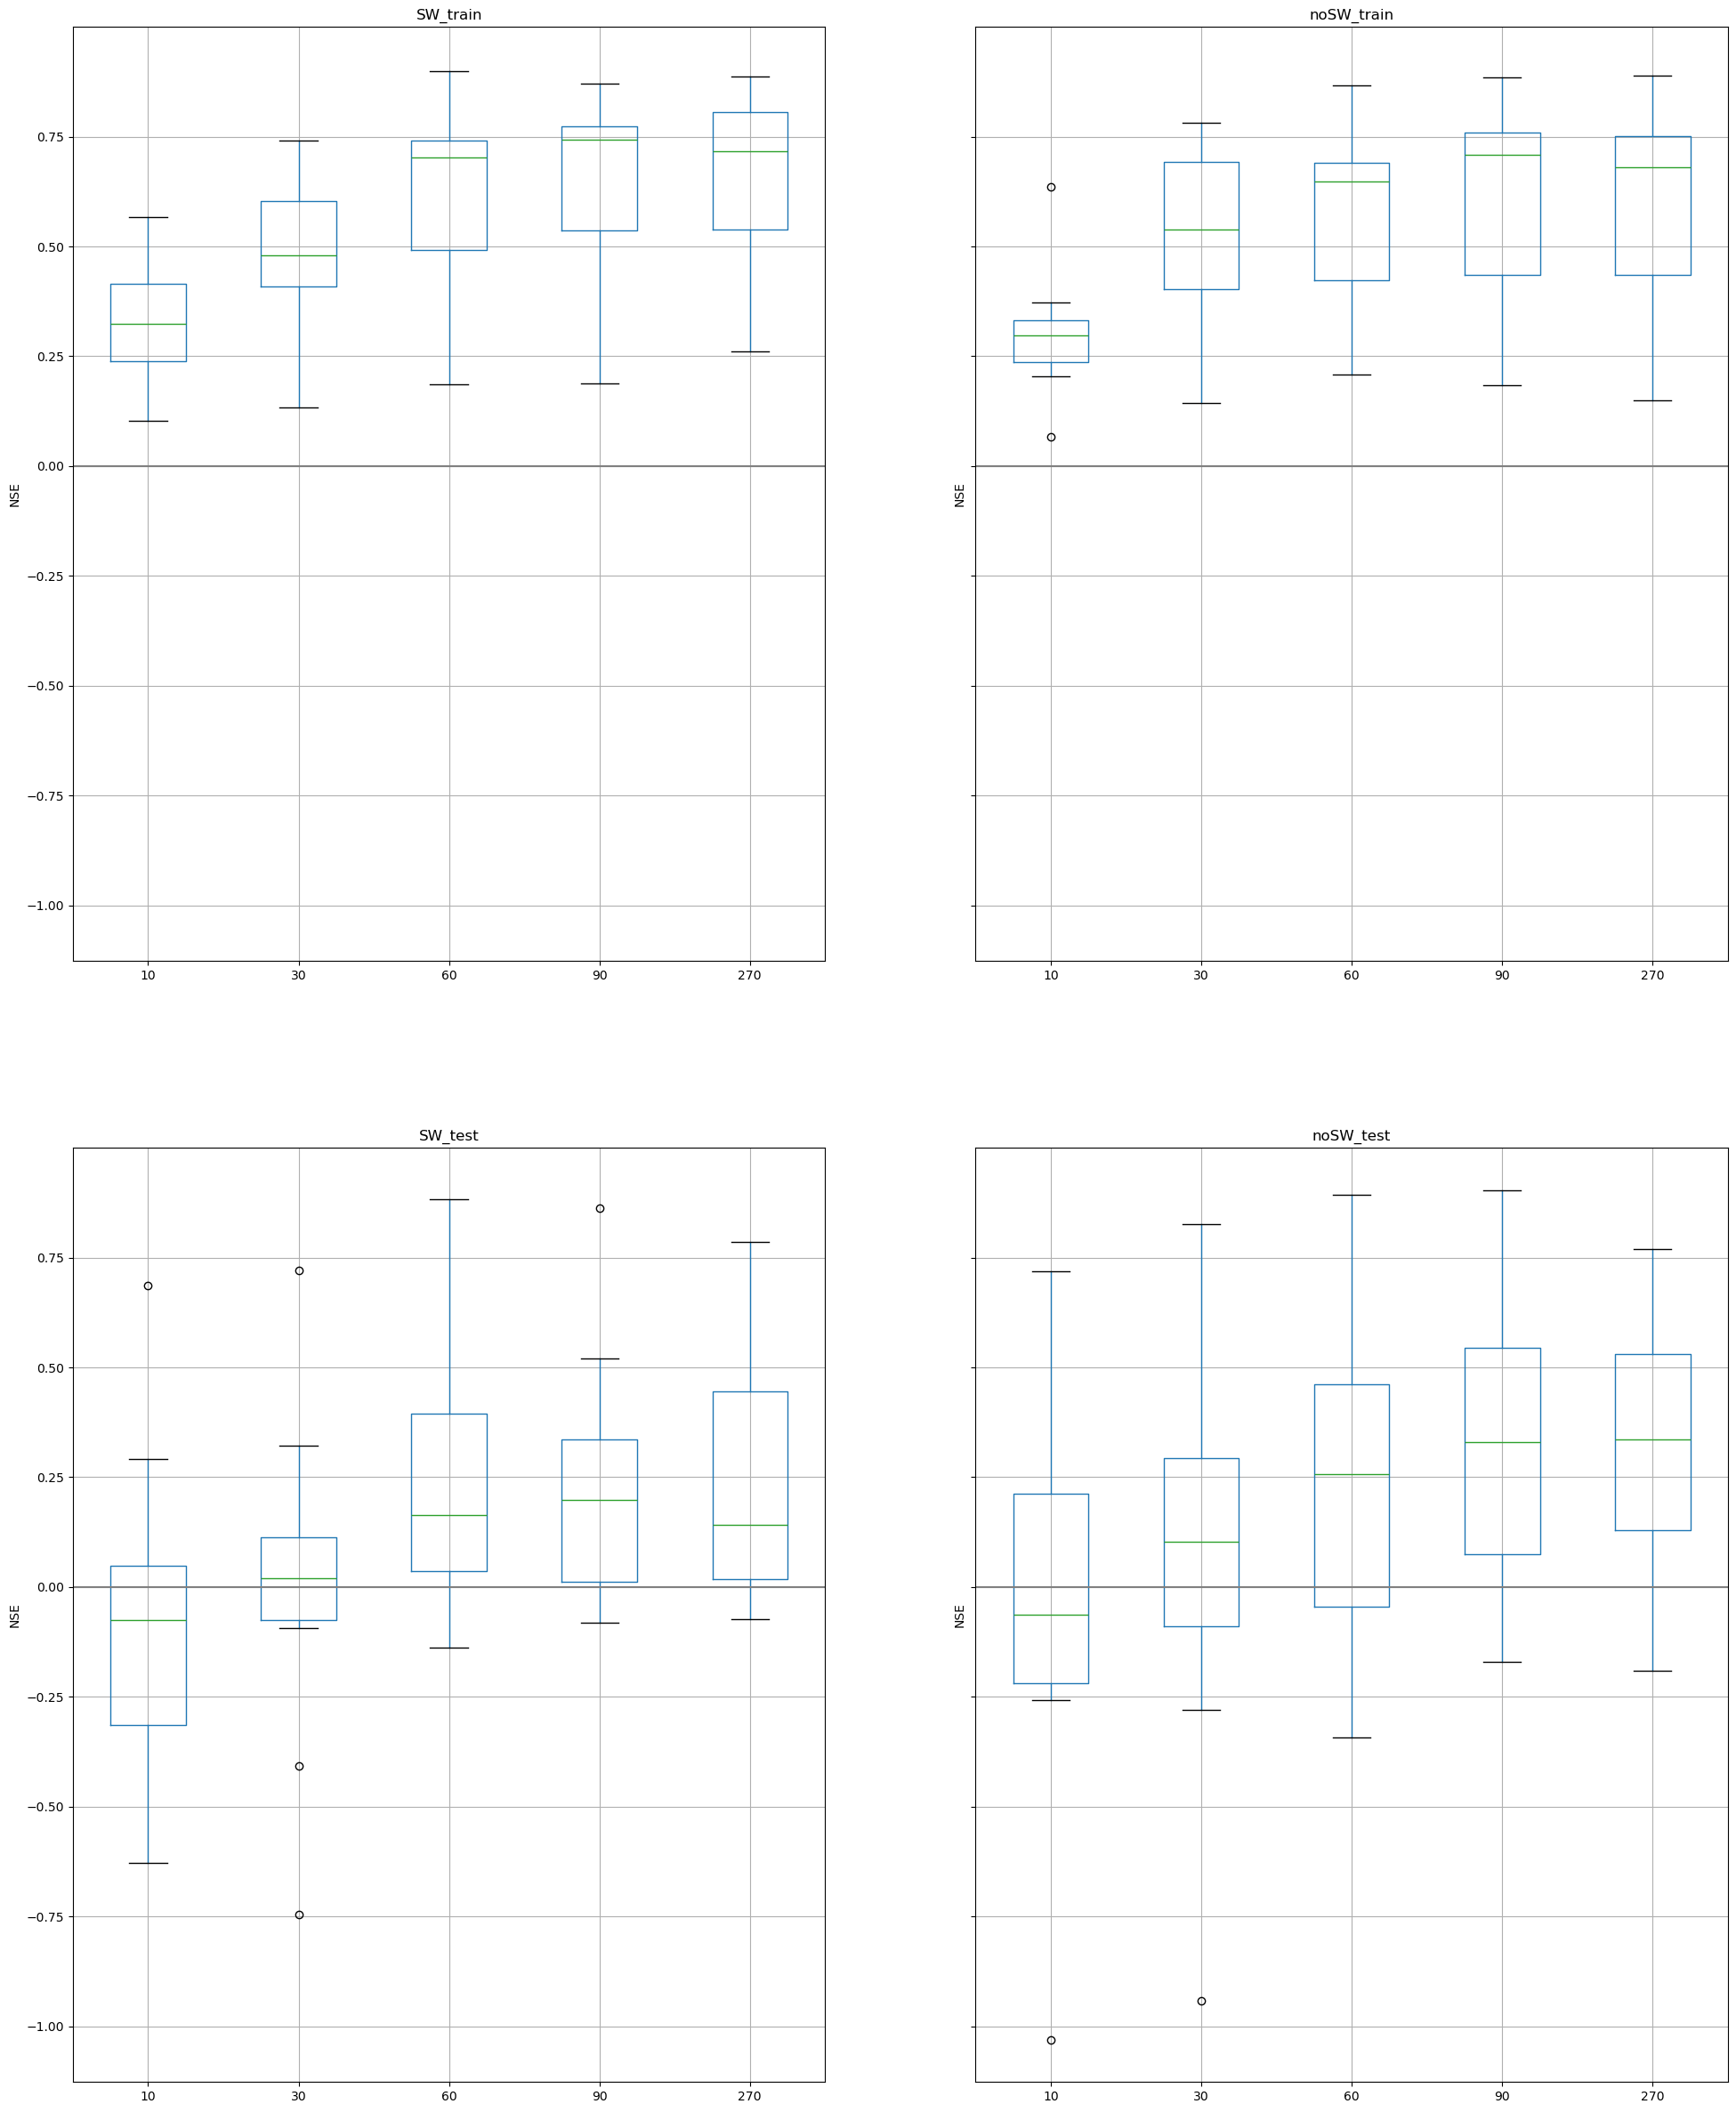

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(24, 30),sharey=True)
seq10_nse_df = comp_plots.boxplot_from_tuple(zipped_metrics[0],ax=axs[0,0],tuple_names=seqlen_options,exp_name = default_order[0])
seq30_nse_df = comp_plots.boxplot_from_tuple(zipped_metrics[1],ax=axs[0,1],tuple_names=seqlen_options,exp_name = default_order[1])
seq60_nse_df = comp_plots.boxplot_from_tuple(zipped_metrics[2],ax=axs[1,0],tuple_names=seqlen_options,exp_name = default_order[2])
seq90_nse_df = comp_plots.boxplot_from_tuple(zipped_metrics[3],ax=axs[1,1],tuple_names=seqlen_options,exp_name = default_order[3])